In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

## Load Original Dataset

In [ ]:
df = pd.read_csv('../../data/phishing_legit_dataset_KD_10000.csv')

print(f"Original dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Original dataset shape: (10000, 5)

Columns: ['text', 'label', 'phishing_type', 'severity', 'confidence']


,text,label,phishing_type,severity,confidence
0,Subject: Office maintenance\n\nThanks for your...,0,legitimate,low,0.95
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69
3,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91
4,"Notice, your profile has been restricted. Use ...",1,credential_harvesting,high,0.80


## Analyze Data Leakage Issues

In [3]:
# Check for "Keywords:" pattern
has_keywords = df['text'].str.contains('Keywords:', case=False, na=False)
print(f"Emails with 'Keywords:' section: {has_keywords.sum()} / {len(df)}")

print("\nBreakdown by phishing type:")
for ptype in df['phishing_type'].unique():
    subset = df[df['phishing_type'] == ptype]
    with_kw = subset['text'].str.contains('Keywords:', case=False, na=False).sum()
    print(f"  {ptype}: {with_kw}/{len(subset)} have Keywords section")

Emails with 'Keywords:' section: 6000 / 10000

Breakdown by phishing type:
  legitimate: 0/4000 have Keywords section
  credential_harvesting: 1000/1000 have Keywords section
  financial_scam: 500/500 have Keywords section
  authority_scam: 500/500 have Keywords section
  urgency: 1000/1000 have Keywords section
  romance_dating: 500/500 have Keywords section
  generic_phishing: 500/500 have Keywords section
  threats: 500/500 have Keywords section
  tech_support: 500/500 have Keywords section
  social_engineering_advanced: 500/500 have Keywords section
  social_engineering: 500/500 have Keywords section


In [4]:
# Show example before cleaning
print("--- Phishing Email Example ---")
phishing_example = df[df['phishing_type'] == 'credential_harvesting'].iloc[0]['text']
print(phishing_example)

print("\n--- Legitimate Email Example ---")
legit_example = df[df['phishing_type'] == 'legitimate'].iloc[0]['text']
print(legit_example)

--- Phishing Email Example ---
Hello, your profile has been locked. Use the secure link to verify your username and restore access. Enter your verification code to continue.

Keywords: pin update password sign in settings password

Sincerely,
Riley Khan

--- Legitimate Email Example ---
Subject: Office maintenance

Thanks for your help on the analysis. I've pushed the changes and left comments in the PR for clarity.

Let me know if the timing works for you.

Best,
Avery Kim


## Clean the Data

In [5]:
def clean_email_text(text):
    """
    Remove data leakage artifacts from email text.
    
    Removes:
    - "Keywords: ..." lines (present only in phishing emails)
    - "Subject: ..." lines (present only in legitimate emails)
    - Extra whitespace and blank lines
    """
    if pd.isna(text):
        return text
    
    # Remove "Keywords: ..." line (matches line starting with Keywords:)
    text = re.sub(r'^Keywords:.*$', '', text, flags=re.MULTILINE | re.IGNORECASE)
    
    # Remove "Subject: ..." line (matches line starting with Subject:)
    text = re.sub(r'^Subject:.*$', '', text, flags=re.MULTILINE | re.IGNORECASE)
    
    # Clean up multiple blank lines (replace with single newline)
    text = re.sub(r'\n\s*\n+', '\n\n', text)
    
    # Strip leading/trailing whitespace
    text = text.strip()
    
    return text

# Apply cleaning
df['text_clean'] = df['text'].apply(clean_email_text)

In [6]:
# Show example after cleaning
print("--- Phishing Email Example ---")
phishing_idx = df[df['phishing_type'] == 'credential_harvesting'].index[0]
print(df.loc[phishing_idx, 'text_clean'])

print("\n--- Legitimate Email Example ---")
legit_idx = df[df['phishing_type'] == 'legitimate'].index[0]
print(df.loc[legit_idx, 'text_clean'])

--- Phishing Email Example ---
Hello, your profile has been locked. Use the secure link to verify your username and restore access. Enter your verification code to continue.

Sincerely,
Riley Khan

--- Legitimate Email Example ---
Thanks for your help on the analysis. I've pushed the changes and left comments in the PR for clarity.

Let me know if the timing works for you.

Best,
Avery Kim


## Compare Text Length Distributions

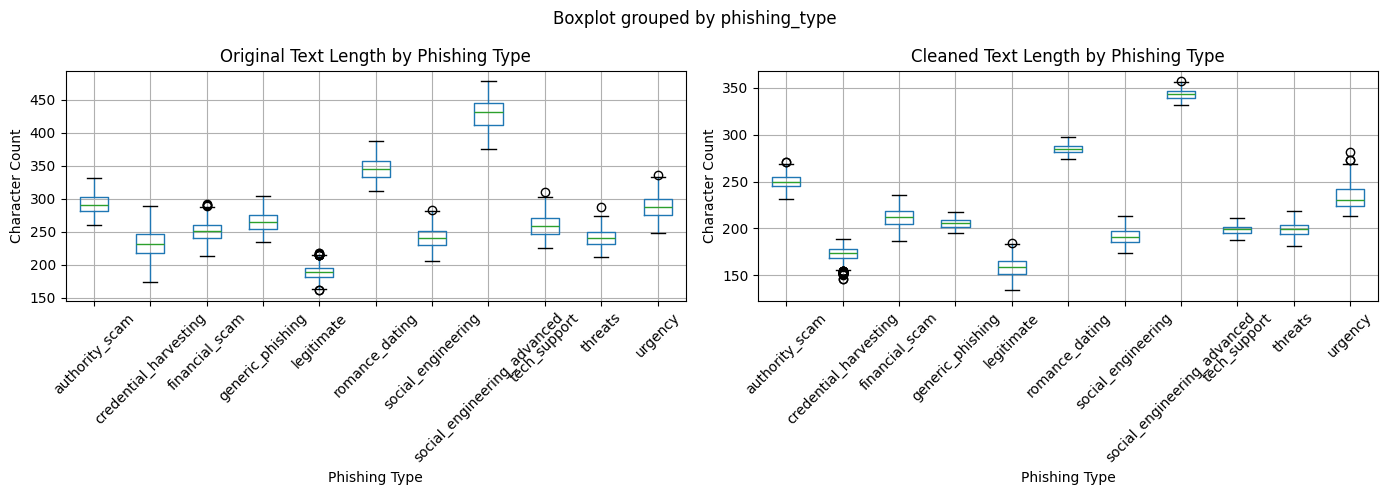

Average characters removed per phishing type:
phishing_type
authority_scam                 42.0
credential_harvesting          58.7
financial_scam                 38.4
generic_phishing               59.6
legitimate                     29.9
romance_dating                 60.9
social_engineering             49.2
social_engineering_advanced    86.2
tech_support                   59.8
threats                        41.1
urgency                        54.0
Name: chars_removed, dtype: float64


In [7]:
# Compare text lengths before and after cleaning
df['len_original'] = df['text'].str.len()
df['len_clean'] = df['text_clean'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original text length by type
df.boxplot(column='len_original', by='phishing_type', ax=axes[0], rot=45)
axes[0].set_title('Original Text Length by Phishing Type')
axes[0].set_xlabel('Phishing Type')
axes[0].set_ylabel('Character Count')

# Cleaned text length by type
df.boxplot(column='len_clean', by='phishing_type', ax=axes[1], rot=45)
axes[1].set_title('Cleaned Text Length by Phishing Type')
axes[1].set_xlabel('Phishing Type')
axes[1].set_ylabel('Character Count')

plt.tight_layout()
plt.show()

print("Average characters removed per phishing type:")
df['chars_removed'] = df['len_original'] - df['len_clean']
print(df.groupby('phishing_type')['chars_removed'].mean().round(1))

## Create Final Cleaned Dataset

In [8]:
# Create the final cleaned dataset
df_clean = df[['text_clean', 'label', 'phishing_type', 'severity', 'confidence']].copy()
df_clean = df_clean.rename(columns={'text_clean': 'text'})

# Drop any rows where cleaning resulted in empty text
df_clean = df_clean[df_clean['text'].str.len() > 10]

print(f"Final cleaned dataset shape: {df_clean.shape}")
print(f"\nPhishing type distribution:")
print(df_clean['phishing_type'].value_counts())

Final cleaned dataset shape: (10000, 5)

Phishing type distribution:
phishing_type
legitimate                     4000
credential_harvesting          1000
urgency                        1000
financial_scam                  500
authority_scam                  500
romance_dating                  500
generic_phishing                500
threats                         500
tech_support                    500
social_engineering_advanced     500
social_engineering              500
Name: count, dtype: int64


## Save Cleaned Dataset

In [ ]:
output_path = '../../data/phishing_legit_dataset_cleaned.csv'
df_clean.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path}")
print(f"Total samples: {len(df_clean)}")

Cleaned dataset saved to: ../data/phishing_legit_dataset_cleaned.csv
Total samples: 10000


## Summary

### Changes Made:
1. **Removed `Keywords:` lines** - These were only present in phishing emails and provided trivial classification signal
2. **Removed `Subject:` lines** - These were only present in legitimate emails and made them easy to identify
3. **Cleaned up whitespace** - Removed extra blank lines created by the removals

This will make the classification task more realistic and the model accuracy should reflect genuine learning rather than dataset artifacts.